<a href="https://colab.research.google.com/github/kjhaveri2321/AHA-Human-Assisted-Out-of-Distribution-Generalization-and-Detection/blob/main/Human_Assisted_Out_of_Distribution_Generalization_and_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human-Assisted OOD Learning with Diversity (AHA + AHA-Diverse)

This notebook studies how models behave on unseen data (OOD).

Implementation:
- AHA (Ambiguity-based selection)
- AHA-Diverse (my own addition of diversity to selection)
- Trained WRN-40-2 on CIFAR-10 and evaluate robustness.


# 1. Imports

In [1]:
# Standard libraries and PyTorch setup
# Includes dataset loading, model building, and visualization tools
import os
import random
import math
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10, SVHN, LSUN, Places365, DTD

from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


# 2. Reproducibility

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


Using device: cuda


# 3. Config

In [28]:
# Central configuration for the entire experiment
# Keeps all hyperparameters in one place for easy tuning and reproducibility
# Important settings:
# - pretrain_epochs: full training on CIFAR-10
# - finetune_epochs: shorter retraining after selection
# - wild_pool_size: number of unlabeled samples we simulate
# - region_std_multiplier: controls how tight the AHA selection region is

@dataclass
class Config:
    data_root: str = './data'
    cifar10c_root: str = './data/CIFAR-10-C'
    batch_size: int = 128
    eval_batch_size: int = 256
    lr: float = 0.1
    momentum: float = 0.9
    weight_decay: float = 5e-4

    # final run settings
    pretrain_epochs: int = 100
    finetune_epochs: int = 20

    num_classes: int = 10
    alpha_ood: float = 10.0
    budget: int = 1000
    labeled_fraction_id: float = 0.5
    wild_pi_c: float = 0.5
    wild_pi_s: float = 0.1
    num_workers: int = 2

    covariate_corruption: str = 'gaussian_noise'
    covariate_severity: int = 1

    semantic_dataset_names: Tuple[str, ...] = ('svhn', 'textures', 'places365')
    score_name: str = 'energy'

    # tighter region than before
    region_std_multiplier: float = 0.20

    # AHA search split
    search_budget_fraction: float = 0.5

    # wild pool
    wild_pool_size: int = 10000

    tsne_points_per_group: int = 300
    save_dir: str = './aha_outputs'

CFG = Config()
os.makedirs(CFG.save_dir, exist_ok=True)
print(CFG)

Config(data_root='./data', cifar10c_root='./data/CIFAR-10-C', batch_size=128, eval_batch_size=256, lr=0.1, momentum=0.9, weight_decay=0.0005, pretrain_epochs=100, finetune_epochs=20, num_classes=10, alpha_ood=10.0, budget=1000, labeled_fraction_id=0.5, wild_pi_c=0.5, wild_pi_s=0.1, num_workers=2, covariate_corruption='gaussian_noise', covariate_severity=1, semantic_dataset_names=('svhn', 'textures', 'places365'), score_name='energy', region_std_multiplier=0.2, search_budget_fraction=0.5, wild_pool_size=10000, tsne_points_per_group=300, save_dir='./aha_outputs')


# 4: Downloading CIFAR-10-C

In [4]:
# This dataset simulates distribution shift by applying corruptions to CIFAR-10 images
# used this to evaluate how well the model generalizes beyond the training distribution
import urllib.request
import tarfile

def download_cifar10c(root="./data"):
    os.makedirs(root, exist_ok=True)
    cifar10c_path = os.path.join(root, "CIFAR-10-C")

    if os.path.exists(cifar10c_path):
        print("CIFAR-10-C already exists.")
        return cifar10c_path

    print("Downloading CIFAR-10-C... This can take a while.")
    url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar"
    tar_path = os.path.join(root, "CIFAR-10-C.tar")

    urllib.request.urlretrieve(url, tar_path)

    print("Extracting CIFAR-10-C...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(path=root)

    os.remove(tar_path)
    print("Done.")
    return cifar10c_path

CFG.cifar10c_root = download_cifar10c(CFG.data_root)
print("CIFAR-10-C path:", CFG.cifar10c_root)


Extracting CIFAR-10-C...


/tmp/ipykernel_748/2028131584.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=root)


Done.
CIFAR-10-C path: ./data/CIFAR-10-C


# 5. Transforms

In [5]:
# All datasets are resized to 32x32 to match CIFAR-10 input size
# This ensures compatibility with WRN-40-2 architecture

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.Resize((32, 32)),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

# 6. WRN-40-2

In [6]:
# WideResNet-40-2 architecture:- This is the backbone model used in the original AHA paper
# I use - classifier head → for normal prediction - OOD head → for detecting semantic OOD samples
class BasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, drop_rate=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.drop_rate = drop_rate
        self.equal_in_out = (in_planes == out_planes)
        self.shortcut = None if self.equal_in_out else nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

    def forward(self, x):
        if not self.equal_in_out:
            x = self.relu1(self.bn1(x))
            out = x
        else:
            out = self.relu1(self.bn1(x))
        out = self.conv1(out)
        out = self.relu2(self.bn2(out))
        if self.drop_rate > 0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        out = self.conv2(out)
        return (x if self.equal_in_out else self.shortcut(x)) + out

class NetworkBlock(nn.Module):
    def __init__(self, nb_layers, in_planes, out_planes, block, stride, drop_rate=0.0):
        super().__init__()
        layers = []
        for i in range(nb_layers):
            layers.append(block(in_planes if i == 0 else out_planes, out_planes, stride if i == 0 else 1, drop_rate))
        self.layer = nn.Sequential(*layers)

    def forward(self, x):
        return self.layer(x)

class WideResNetAHA(nn.Module):
    def __init__(self, depth=40, widen_factor=2, num_classes=10, drop_rate=0.0):
        super().__init__()
        assert (depth - 4) % 6 == 0
        n = (depth - 4) // 6
        k = widen_factor
        n_channels = [16, 16 * k, 32 * k, 64 * k]

        self.conv1 = nn.Conv2d(3, n_channels[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.block1 = NetworkBlock(n, n_channels[0], n_channels[1], BasicBlock, 1, drop_rate)
        self.block2 = NetworkBlock(n, n_channels[1], n_channels[2], BasicBlock, 2, drop_rate)
        self.block3 = NetworkBlock(n, n_channels[2], n_channels[3], BasicBlock, 2, drop_rate)
        self.bn1 = nn.BatchNorm2d(n_channels[3])
        self.relu = nn.ReLU(inplace=True)
        self.feature_dim = n_channels[3]
        self.classifier = nn.Linear(self.feature_dim, num_classes)
        self.ood_head = nn.Linear(self.feature_dim, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.relu(self.bn1(x))
        x = F.adaptive_avg_pool2d(x, 1)
        feat = x.view(x.size(0), -1)
        logits = self.classifier(feat)
        ood_logit = self.ood_head(feat).squeeze(1)
        return logits, ood_logit, feat


# 7. Dataset wrappers

In [7]:
# Custom dataset wrapper for mixing different data types
# Each sample is stored as: (image, class_label, is_semantic_ood)
# - class_label = -1 → semantic OOD
# - is_semantic_ood = 1 → semantic OOD flag
# This allows us to train both classification and OOD detection jointly

class LabeledOODDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]

class CIFAR10CProxy(Dataset):
    def __init__(self, root, corruption='gaussian_noise', severity=1, transform=None):
        self.root = root
        self.corruption = corruption
        self.severity = severity
        self.transform = transform

        corruption_path = os.path.join(root, f'{corruption}.npy')
        labels_path = os.path.join(root, 'labels.npy')
        if not os.path.exists(corruption_path) or not os.path.exists(labels_path):
            raise FileNotFoundError(
                f'Missing CIFAR-10-C files at {root}. '
                f'Expected {corruption}.npy and labels.npy'
            )

        data = np.load(corruption_path)
        labels = np.load(labels_path)
        start = (severity - 1) * 10000
        end = severity * 10000
        self.data = data[start:end]
        self.labels = labels[start:end]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = int(self.labels[idx])
        img = torchvision.transforms.functional.to_pil_image(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

class SemanticOODWrapper(Dataset):
    def __init__(self, base_dataset, name='ood'):
        self.base_dataset = base_dataset
        self.name = name

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        return img, -1


# 8. Data loading helpers

In [8]:
# Splits CIFAR-10 into:- labeled set (used for training), unlabeled set (used to simulate "wild" data)
# Also loads semantic OOD datasets: SVHN (digits), Textures (patterns), Places365 (scene images)
# These datasets represent different types of distribution shift

def build_cifar10_splits():
    full_train_plain = CIFAR10(root=CFG.data_root, train=True, download=True, transform=test_transform)
    full_train_aug = CIFAR10(root=CFG.data_root, train=True, download=True, transform=train_transform)
    test_id = CIFAR10(root=CFG.data_root, train=False, download=True, transform=test_transform)

    indices = np.arange(len(full_train_plain))
    np.random.shuffle(indices)
    split = int(CFG.labeled_fraction_id * len(indices))
    labeled_idx = indices[:split]
    unlabeled_idx = indices[split:]

    Sin_plain = Subset(full_train_plain, labeled_idx)
    Sin_aug = Subset(full_train_aug, labeled_idx)
    Sunlabeled_plain = Subset(full_train_plain, unlabeled_idx)
    return Sin_plain, Sin_aug, Sunlabeled_plain, test_id


def get_semantic_dataset(name: str):
    name = name.lower()

    if name == 'svhn':
        ds = SVHN(
            root=CFG.data_root,
            split='test',
            download=True,
            transform=test_transform
        )

    elif name == 'textures':
        ds = DTD(
            root=CFG.data_root,
            split='test',
            download=True,
            transform=test_transform
        )

    elif name == 'places365':
        ds = Places365(
            root=CFG.data_root,
            split='val',
            small=True,
            download=True,
            transform=test_transform
        )

    else:
        raise ValueError(f'Unknown semantic OOD dataset: {name}')

    return SemanticOODWrapper(ds, name=name)


def build_covariate_dataset():
    return CIFAR10CProxy(
        root=CFG.cifar10c_root,
        corruption=CFG.covariate_corruption,
        severity=CFG.covariate_severity,
        transform=test_transform,
    )

# 9. Wild mixture helpers


In [9]:
# Builds a mixed "wild" dataset containing:
# - in-distribution samples
# - covariate OOD samples (CIFAR-10-C)
# - semantic OOD samples (SVHN / Textures / Places)
# Which simulates a real-world deployment scenario where data is not cleanly separated

def sample_dataset_items(dataset, n_samples, semantic=False):
    indices = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)
    items = []
    for idx in indices:
        img, label = dataset[idx]
        class_label = -1 if semantic else int(label)
        is_semantic = 1 if semantic else 0
        items.append((img, class_label, is_semantic))
    return items

def build_wild_pool(unlabeled_id, covariate_ds, semantic_ds, total_size=10000):
    n_cov = int(total_size * CFG.wild_pi_c)
    n_sem = int(total_size * CFG.wild_pi_s)
    n_id = total_size - n_cov - n_sem

    wild_items = []
    wild_items += sample_dataset_items(unlabeled_id, n_id, semantic=False)
    wild_items += sample_dataset_items(covariate_ds, n_cov, semantic=False)
    wild_items += sample_dataset_items(semantic_ds, n_sem, semantic=True)
    random.shuffle(wild_items)
    return wild_items


# 10. Score functions


In [10]:
# Energy-based OOD score
# Lower (more negative) → likely ID
# Higher (less negative) → likely OOD
#
# This score is used both for:
# - ranking samples
# - thresholding during evaluation

def energy_score(logits):
    return -torch.logsumexp(logits, dim=1)

def compute_score(logits, score_name='energy'):
    if score_name == 'energy':
        return energy_score(logits)
    raise ValueError(f'Unknown score: {score_name}')

# 11. Training and evaluation helpers


In [11]:
# Pretraining stage: The model is trained on labeled CIFAR-10 data only
import copy

def collate_train(batch):
    imgs, class_labels, is_semantic = zip(*batch)
    return torch.stack(imgs), torch.tensor(class_labels), torch.tensor(is_semantic)

def build_training_items(Sin_aug, selected_items):
    train_items = []
    for i in range(len(Sin_aug)):
        img, label = Sin_aug[i]
        train_items.append((img, int(label), 0))
    train_items.extend(selected_items)
    return LabeledOODDataset(train_items)

def build_eval_loader(ds):
    return DataLoader(ds, batch_size=CFG.eval_batch_size, shuffle=False, num_workers=CFG.num_workers)

def pretrain_on_id(model, Sin_aug):
    ds = build_training_items(Sin_aug, [])
    loader = DataLoader(
        ds,
        batch_size=CFG.batch_size,
        shuffle=True,
        num_workers=CFG.num_workers,
        collate_fn=collate_train
    )

    optimizer = optim.SGD(
        model.parameters(),
        lr=CFG.lr,
        momentum=CFG.momentum,
        weight_decay=CFG.weight_decay,
        nesterov=True
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.pretrain_epochs)
    ce = nn.CrossEntropyLoss()

    for epoch in range(CFG.pretrain_epochs):
        model.train()
        for imgs, class_labels, _ in loader:
            imgs = imgs.to(DEVICE)
            class_labels = class_labels.to(DEVICE)

            logits, _, _ = model(imgs)
            loss = ce(logits, class_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'[Pretrain] Epoch {epoch+1}/{CFG.pretrain_epochs}')
    return model

def get_fresh_model_from_base(base_model):
    new_model = WideResNetAHA(depth=40, widen_factor=2, num_classes=CFG.num_classes).to(DEVICE)
    new_model.load_state_dict(copy.deepcopy(base_model.state_dict()))
    return new_model

def score_wild_pool(model, wild_items, score_name='energy'):
    dataset = LabeledOODDataset(wild_items)
    loader = DataLoader(
        dataset,
        batch_size=CFG.eval_batch_size,
        shuffle=False,
        num_workers=CFG.num_workers,
        collate_fn=collate_train
    )

    scores, feats, labels_sem = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, _, is_semantic in loader:
            imgs = imgs.to(DEVICE)
            logits, _, feat = model(imgs)
            s = compute_score(logits, score_name=score_name)

            scores.append(s.cpu().numpy())
            feats.append(feat.cpu().numpy())
            labels_sem.append(is_semantic.numpy())

    return np.concatenate(scores), np.concatenate(feats), np.concatenate(labels_sem)

# 12. Selection methods


In [12]:
# Sample selection strategies
# Top-k:- selects highest OOD-score samples (extreme examples)
# AHA:- approximates the ambiguity region where the model is most uncertain, using a score-based threshold estimation
# AHA-Diverse:- extends AHA by enforcing diversity in feature space using clustering (KMeans)

def estimate_aha_threshold_from_queries(scores, is_semantic_labels, search_budget):
    order = np.argsort(scores)
    ordered_scores = scores[order]
    ordered_labels = is_semantic_labels[order]

    # chooses search points evenly across sorted scores
    probe_positions = np.linspace(0, len(order) - 1, search_budget).astype(int)
    probe_scores = ordered_scores[probe_positions]
    probe_labels = ordered_labels[probe_positions]

    # converts semantic OOD -> -1, non-semantic -> +1
    signed = np.where(probe_labels == 1, -1, 1)

    # cumulative objective from paper-style approximation
    cumulative = np.cumsum(signed)

    best_idx = np.argmax(cumulative)
    threshold = probe_scores[best_idx]
    return threshold

def aha_select_indices(scores, is_semantic_labels, budget, std_multiplier=0.2):
    search_budget = int(budget * CFG.search_budget_fraction)
    label_budget = budget - search_budget

    threshold = estimate_aha_threshold_from_queries(scores, is_semantic_labels, search_budget)

    std = np.std(scores)
    low = threshold - std_multiplier * std
    high = threshold + std_multiplier * std

    candidate = np.where((scores >= low) & (scores <= high))[0]
    if len(candidate) < label_budget:
        candidate = np.argsort(np.abs(scores - threshold))[:label_budget]

    candidate_scores = scores[candidate]
    left = candidate[candidate_scores <= threshold]
    right = candidate[candidate_scores > threshold]

    n_left = min(len(left), label_budget // 2)
    n_right = min(len(right), label_budget - n_left)

    left_sorted = left[np.argsort(np.abs(scores[left] - threshold))[:n_left]] if len(left) > 0 else np.array([], dtype=int)
    right_sorted = right[np.argsort(np.abs(scores[right] - threshold))[:n_right]] if len(right) > 0 else np.array([], dtype=int)

    selected_label_phase = np.concatenate([left_sorted, right_sorted])

    # includes the queried search points as part of budget
    order = np.argsort(scores)
    probe_positions = np.linspace(0, len(order) - 1, search_budget).astype(int)
    selected_search = order[probe_positions]

    selected = np.concatenate([selected_search, selected_label_phase])
    selected = np.unique(selected)

    if len(selected) < budget:
        remaining = np.setdiff1d(np.argsort(np.abs(scores - threshold)), selected)
        selected = np.concatenate([selected, remaining[:budget - len(selected)]])

    return selected[:budget], threshold, (low, high)

def aha_diverse_select_indices(scores, feats, is_semantic_labels, budget, std_multiplier=0.2):
    search_budget = int(budget * CFG.search_budget_fraction)
    label_budget = budget - search_budget

    threshold = estimate_aha_threshold_from_queries(scores, is_semantic_labels, search_budget)

    std = np.std(scores)
    low = threshold - std_multiplier * std
    high = threshold + std_multiplier * std

    region = np.where((scores >= low) & (scores <= high))[0]
    if len(region) < max(label_budget, 10):
        region = np.argsort(np.abs(scores - threshold))[:max(label_budget * 2, label_budget)]

    region_feats = feats[region]

    k = min(label_budget, len(region))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(region_feats)

    selected_label_phase = []
    for c in kmeans.cluster_centers_:
        d = np.linalg.norm(region_feats - c, axis=1)
        selected_label_phase.append(region[np.argmin(d)])

    selected_label_phase = np.array(sorted(set(selected_label_phase)))

    order = np.argsort(scores)
    probe_positions = np.linspace(0, len(order) - 1, search_budget).astype(int)
    selected_search = order[probe_positions]

    selected = np.concatenate([selected_search, selected_label_phase])
    selected = np.unique(selected)

    if len(selected) < budget:
        remaining = np.setdiff1d(region, selected)
        selected = np.concatenate([selected, remaining[:budget - len(selected)]])

    return selected[:budget], threshold, (low, high)

def random_select_indices(scores, budget):
    idx = np.arange(len(scores))
    chosen = np.random.choice(idx, size=min(budget, len(idx)), replace=False)
    return chosen, None, None

def topk_ood_select_indices(scores, budget):
    idx = np.argsort(scores)[-budget:]
    return idx, None, None

# 13. Finetuning and metrics


In [23]:
# Finetuning stage
# The model is retrained using:
# - original labeled data
# - selected samples from the wild pool

# This step integrates human-assisted labeling into training

def finetune_with_selected(model, Sin_aug, selected_items, epochs=30):
    train_dataset = build_training_items(Sin_aug, selected_items)
    loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, collate_fn=collate_train)

    optimizer = optim.SGD(model.parameters(), lr=CFG.lr * 0.2, momentum=CFG.momentum, weight_decay=CFG.weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    ce = nn.CrossEntropyLoss()
    bce = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        for imgs, class_labels, is_semantic in loader:
            imgs = imgs.to(DEVICE)
            class_labels = class_labels.to(DEVICE)
            is_semantic = is_semantic.float().to(DEVICE)

            logits, ood_logits, _ = model(imgs)
            id_mask = class_labels >= 0
            loss_cls = ce(logits[id_mask], class_labels[id_mask]) if id_mask.any() else torch.tensor(0.0, device=DEVICE)
            loss_ood = bce(ood_logits, is_semantic)
            loss = loss_cls + CFG.alpha_ood * loss_ood

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[Finetune] Epoch {epoch+1}/{epochs}')
    return model

def evaluate_id_accuracy(model, test_id):
    loader = DataLoader(test_id, batch_size=CFG.eval_batch_size, shuffle=False, num_workers=CFG.num_workers)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits, _, _ = model(imgs)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

def evaluate_covariate_accuracy(model, covariate_ds):
    loader = DataLoader(covariate_ds, batch_size=CFG.eval_batch_size, shuffle=False, num_workers=CFG.num_workers)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits, _, _ = model(imgs)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

def get_scores_for_loader(model, loader, score_name='energy'):
    all_scores = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            imgs = batch[0].to(DEVICE)
            logits, _, _ = model(imgs)
            s = compute_score(logits, score_name=score_name)
            all_scores.append(s.cpu().numpy())
    return np.concatenate(all_scores)

def compute_fpr95_and_auroc(model, id_dataset, semantic_dataset, score_name='energy'):
    id_loader = build_eval_loader(id_dataset)
    sem_loader = build_eval_loader(semantic_dataset)

    id_scores = get_scores_for_loader(model, id_loader, score_name)
    sem_scores = get_scores_for_loader(model, sem_loader, score_name)

    # Correct threshold: 95% TPR → 95th percentile of ID
    threshold = np.percentile(id_scores, 95)

    # FPR: how many OOD are misclassified as ID
    fpr95 = 100.0 * np.mean(sem_scores <= threshold)

    # AUROC stays same
    y_true = np.concatenate([np.zeros_like(id_scores), np.ones_like(sem_scores)])
    y_score = np.concatenate([id_scores, sem_scores])
    auroc = 100.0 * roc_auc_score(y_true, y_score)

    return fpr95, auroc, threshold, id_scores, sem_scores


# 14. Presentation plots


In [37]:
def extract_scores_for_dataset(model, dataset, score_name='energy'):
    loader = build_eval_loader(dataset)
    return get_scores_for_loader(model, loader, score_name)

def plot_score_distributions(id_scores, cov_scores, sem_scores, title='OOD Score Distributions', save_path=None):
    plt.figure(figsize=(8, 5))
    bins = np.linspace(-10, 10, 100)
    plt.hist(id_scores, bins=bins, alpha=0.5, density=True, label='ID')
    plt.hist(cov_scores, bins=bins, alpha=0.5, density=True, label='Covariate OOD')
    plt.hist(sem_scores, bins=bins, alpha=0.5, density=True, label='Semantic OOD')
    plt.xlim(-10, 10)
    plt.ylim(0, 0.5)
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

def unnormalize(img_tensor):
    img = img_tensor.clone().cpu()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return torch.clamp(img, 0, 1)

def show_selected_examples_with_predictions(
    model,
    wild_items,
    selected_idx,
    id_scores_eval,
    n=16,
    title='Selected examples'
):
    n = min(n, len(selected_idx))
    cols = 4
    rows = math.ceil(n / cols)

    # Same threshold rule used in evaluation
    threshold = np.percentile(id_scores_eval, 95)

    plt.figure(figsize=(3 * cols, 3.4 * rows))
    model.eval()

    for i, idx in enumerate(selected_idx[:n]):
        img, class_label, is_semantic = wild_items[idx]

        x = img.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits, _, _ = model(x)
            pred_class = logits.argmax(dim=1).item()
            score = energy_score(logits).item()

        is_ood_pred = score > threshold

        # infer sample type
        if is_semantic == 1:
            sample_type = "Semantic OOD"
            true_label = "Semantic OOD"
        else:
            # heuristic: very rough way to tag likely covariate vs ID from selected pool
            # if score is close to semantic side, it is more likely covariate OOD
            sample_type = "ID / Covariate OOD"
            true_label = f"Class {class_label}"

        ood_text = "Yes" if is_ood_pred else "No"
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.transpose(unnormalize(img).numpy(), (1, 2, 0)))
        plt.axis('off')

        title_text = (
            f"Type: {sample_type}\n"
            f"True: {true_label}\n"
            f"Pred: Class {pred_class} | OOD: {ood_text}\n"
            f"Score: {score:.2f}"
        )
        plt.title(title_text, fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_tsne_features(model, id_dataset, cov_dataset, sem_dataset, title='t-SNE of Features', save_path=None):
    def sample_feats(ds, label_tag, max_n):
        loader = DataLoader(ds, batch_size=CFG.eval_batch_size, shuffle=True, num_workers=CFG.num_workers)
        feats = []
        tags = []
        count = 0
        model.eval()
        with torch.no_grad():
            for batch in loader:
                imgs = batch[0].to(DEVICE)
                _, _, f = model(imgs)
                feats.append(f.cpu().numpy())
                tags.extend([label_tag] * len(imgs))
                count += len(imgs)
                if count >= max_n:
                    break
        feats = np.concatenate(feats, axis=0)[:max_n]
        tags = tags[:max_n]
        return feats, tags

    id_feats, id_tags = sample_feats(id_dataset, 'ID', CFG.tsne_points_per_group)
    cov_feats, cov_tags = sample_feats(cov_dataset, 'Covariate OOD', CFG.tsne_points_per_group)
    sem_feats, sem_tags = sample_feats(sem_dataset, 'Semantic OOD', CFG.tsne_points_per_group)

    all_feats = np.concatenate([id_feats, cov_feats, sem_feats], axis=0)
    all_tags = id_tags + cov_tags + sem_tags

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
    emb = tsne.fit_transform(all_feats)

    plt.figure(figsize=(8, 6))
    for label in ['ID', 'Covariate OOD', 'Semantic OOD']:
        idx = [i for i, t in enumerate(all_tags) if t == label]
        plt.scatter(emb[idx, 0], emb[idx, 1], s=10, alpha=0.6, label=label)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# 15. End-to-end experiment


In [25]:
# Runs a full experiment pipeline:
# - scoring
# - selection
# - finetuning
# - evaluation
# - Each method is tested independently using the same base model

BASE_PRETRAINED_MODEL = None
BASE_SPLITS = None

def prepare_base_model_once():
    global BASE_PRETRAINED_MODEL, BASE_SPLITS

    if BASE_PRETRAINED_MODEL is not None and BASE_SPLITS is not None:
        print("Using cached pretrained base model.")
        return BASE_PRETRAINED_MODEL, BASE_SPLITS

    print("Preparing CIFAR splits and pretraining base WRN-40-2 once...")
    Sin_plain, Sin_aug, Sunlabeled_plain, test_id = build_cifar10_splits()

    base_model = WideResNetAHA(depth=40, widen_factor=2, num_classes=CFG.num_classes).to(DEVICE)
    base_model = pretrain_on_id(base_model, Sin_aug)

    BASE_PRETRAINED_MODEL = base_model
    BASE_SPLITS = (Sin_plain, Sin_aug, Sunlabeled_plain, test_id)
    return BASE_PRETRAINED_MODEL, BASE_SPLITS

def run_single_experiment(semantic_name='svhn', method='aha'):
    print('=' * 80)
    print(f'Running semantic OOD dataset: {semantic_name} | method: {method}')
    print('=' * 80)

    base_model, splits = prepare_base_model_once()
    Sin_plain, Sin_aug, Sunlabeled_plain, test_id = splits

    covariate_ds = build_covariate_dataset()
    semantic_ds = get_semantic_dataset(semantic_name)
    wild_items = build_wild_pool(
        Sunlabeled_plain,
        covariate_ds,
        semantic_ds,
        total_size=CFG.wild_pool_size
    )

    scores, feats, is_semantic_labels = score_wild_pool(base_model, wild_items, score_name=CFG.score_name)

    if method == 'aha':
        selected_idx, threshold, region = aha_select_indices(
            scores, is_semantic_labels, CFG.budget, CFG.region_std_multiplier
        )
    elif method == 'aha_diverse':
        selected_idx, threshold, region = aha_diverse_select_indices(
            scores, feats, is_semantic_labels, CFG.budget, CFG.region_std_multiplier
        )
    elif method == 'topk':
        selected_idx, threshold, region = topk_ood_select_indices(scores, CFG.budget)
    elif method == 'random':
        selected_idx, threshold, region = random_select_indices(scores, CFG.budget)
    else:
        raise ValueError(f'Unknown method: {method}')

    selected_items = [wild_items[i] for i in selected_idx]

    model = get_fresh_model_from_base(base_model)

    print('Finetuning from cached pretrained model...')
    model = finetune_with_selected(model, Sin_aug, selected_items, epochs=CFG.finetune_epochs)

    print('Evaluating...')
    id_acc = evaluate_id_accuracy(model, test_id)
    cov_acc = evaluate_covariate_accuracy(model, covariate_ds)
    fpr95, auroc, id_threshold, id_scores, sem_scores = compute_fpr95_and_auroc(
        model, test_id, semantic_ds, CFG.score_name
    )
    cov_scores = extract_scores_for_dataset(model, covariate_ds, CFG.score_name)

    return {
        'semantic_dataset': semantic_name,
        'method': method,
        'id_acc': id_acc,
        'ood_acc': cov_acc,
        'fpr95': fpr95,
        'auroc': auroc,
        'selection_threshold': threshold,
        'id_threshold_95tpr': id_threshold,
        'wild_items': wild_items,
        'selected_idx': selected_idx,
        'id_scores_eval': id_scores,
        'cov_scores_eval': cov_scores,
        'sem_scores_eval': sem_scores,
        'model': model,
        'test_id': test_id,
        'covariate_ds': covariate_ds,
        'semantic_ds': semantic_ds,
    }

# 16. Benchmark helper


In [26]:
# Runs experiments across multiple datasets and methods
# Produces a table comparing:
# - Top-k
# - AHA
# - AHA-Diverse

def benchmark_methods(methods=('topk', 'aha', 'aha_diverse'), semantic_names=None):
    if semantic_names is None:
        semantic_names = CFG.semantic_dataset_names

    rows = []
    for semantic_name in semantic_names:
        for method in methods:
            try:
                out = run_single_experiment(semantic_name=semantic_name, method=method)
                rows.append({
                    'semantic_dataset': semantic_name,
                    'method': method,
                    'OOD Acc': out['ood_acc'],
                    'ID Acc': out['id_acc'],
                    'FPR95': out['fpr95'],
                    'AUROC': out['auroc'],
                })
            except Exception as e:
                print(f'Failed on semantic={semantic_name}, method={method}: {e}')
    return rows


# Visualization  

Running semantic OOD dataset: svhn | method: aha
Using cached pretrained base model.
Finetuning from cached pretrained model...
[Finetune] Epoch 1/20
[Finetune] Epoch 5/20
[Finetune] Epoch 10/20
[Finetune] Epoch 15/20
[Finetune] Epoch 20/20
Evaluating...
Running semantic OOD dataset: svhn | method: aha_diverse
Using cached pretrained base model.
Finetuning from cached pretrained model...
[Finetune] Epoch 1/20
[Finetune] Epoch 5/20
[Finetune] Epoch 10/20
[Finetune] Epoch 15/20
[Finetune] Epoch 20/20
Evaluating...


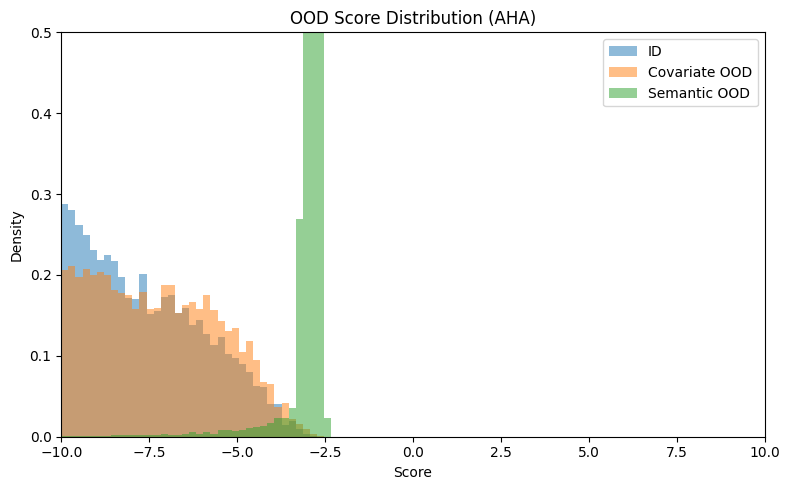

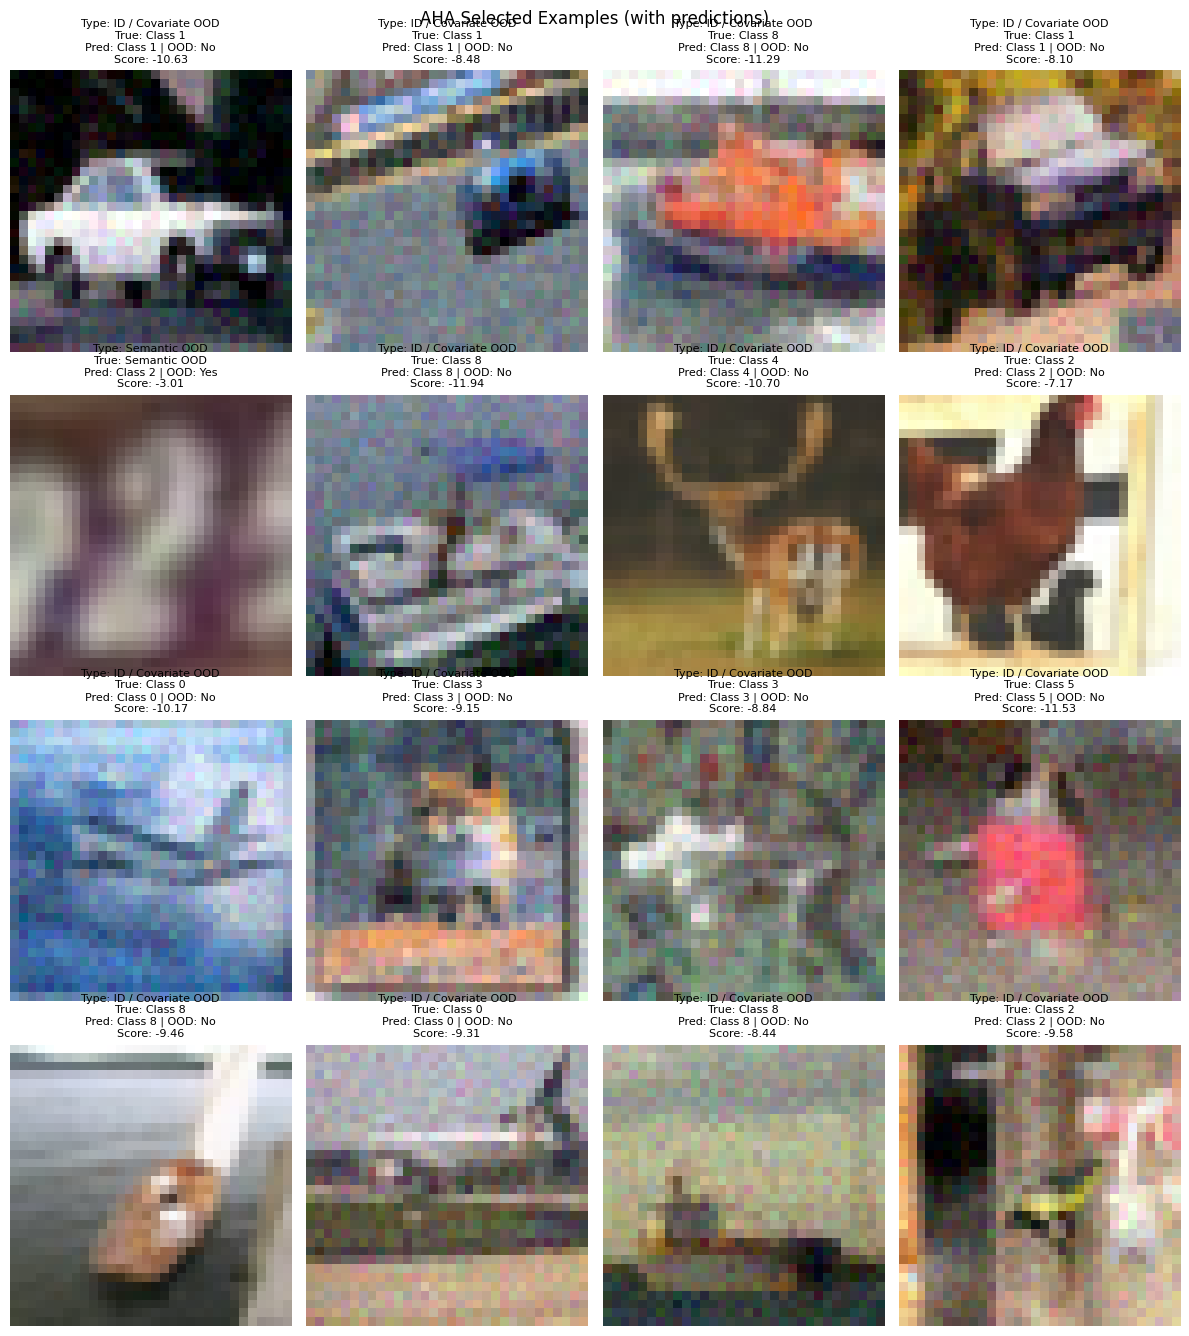

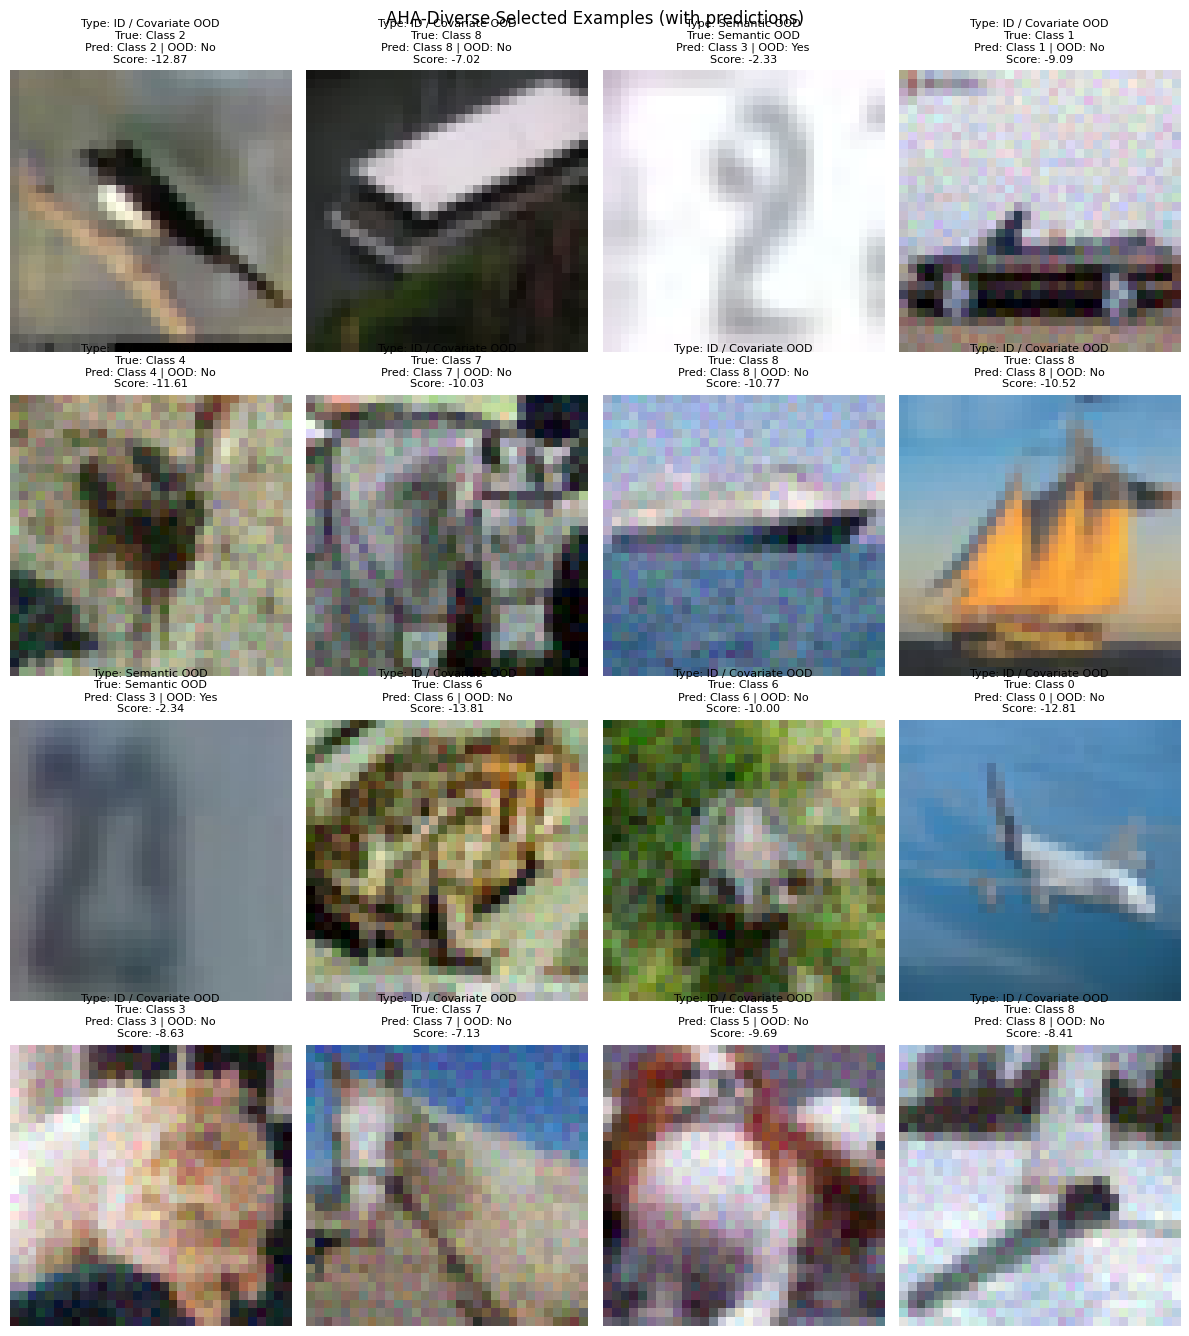

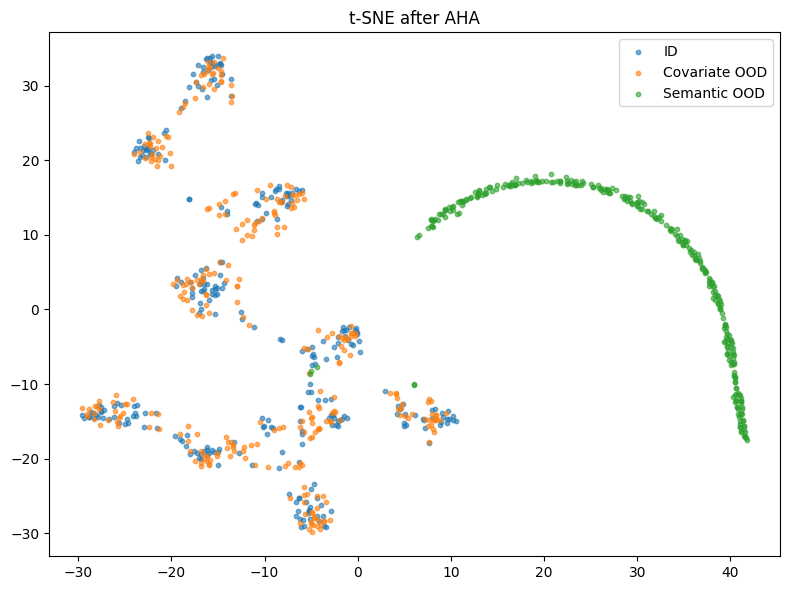

In [36]:
# Visualizes selected samples with:
# - true label
# - predicted class
# - OOD decision
# - energy score
# - Helps understand what kinds of samples each method selects

result_aha = run_single_experiment(semantic_name="svhn", method="aha")
result_div = run_single_experiment(semantic_name="svhn", method="aha_diverse")

# Score distribution plot
plot_score_distributions(
    result_aha['id_scores_eval'],
    result_aha['cov_scores_eval'],
    result_aha['sem_scores_eval'],
    title='OOD Score Distribution (AHA)'
)

# Selected examples
show_selected_examples_with_predictions(
    result_aha['model'],
    result_aha['wild_items'],
    result_aha['selected_idx'],
    result_aha['id_scores_eval'],
    n=16,
    title='AHA Selected Examples (with predictions)'
)

show_selected_examples_with_predictions(
    result_div['model'],
    result_div['wild_items'],
    result_div['selected_idx'],
    result_div['id_scores_eval'],
    n=16,
    title='AHA-Diverse Selected Examples (with predictions)'
)

# t-SNE
plot_tsne_features(
    result_aha['model'],
    result_aha['test_id'],
    result_aha['covariate_ds'],
    result_aha['semantic_ds'],
    title='t-SNE after AHA'
)

# 17. Quantitative Analysis

In [29]:
import pandas as pd

def multi_dataset_table(
    semantic_names=None,
    methods=("topk", "aha", "aha_diverse")
):
    if semantic_names is None:
        semantic_names = CFG.semantic_dataset_names

    rows = []

    for dataset_name in semantic_names:
        for method_name in methods:
            try:
                print("=" * 80)
                print(f"Running method={method_name} on semantic OOD dataset={dataset_name}")
                print("=" * 80)

                result = run_single_experiment(
                    semantic_name=dataset_name,
                    method=method_name
                )

                rows.append({
                    "Dataset": dataset_name,
                    "Method": method_name,
                    "ID Acc": round(result["id_acc"], 2),
                    "OOD Acc": round(result["ood_acc"], 2),
                    "FPR95": round(result["fpr95"], 2),
                    "AUROC": round(result["auroc"], 2),
                })

            except Exception as e:
                print(f"FAILED: dataset={dataset_name}, method={method_name}")
                print("Reason:", e)

    return pd.DataFrame(rows)

# 18. Average Result table

In [19]:
def average_results_table(df):
    avg_df = (
        df.groupby("Method")[["ID Acc", "OOD Acc", "FPR95", "AUROC"]]
        .mean()
        .round(2)
        .reset_index()
    )
    return avg_df

# 19. Final benchmark run

In [30]:
prepare_base_model_once()


Using cached pretrained base model.


(WideResNetAHA(
   (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (block1): NetworkBlock(
     (layer): Sequential(
       (0): BasicBlock(
         (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu1): ReLU(inplace=True)
         (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu2): ReLU(inplace=True)
         (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (shortcut): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
       )
       (1): BasicBlock(
         (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu1): ReLU(inplace=True)
         (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2):

In [31]:
multi_results = multi_dataset_table(
    semantic_names=("svhn", "textures", "places365"),
    methods=("topk", "aha", "aha_diverse")
)
multi_results

Running method=topk on semantic OOD dataset=svhn
Running semantic OOD dataset: svhn | method: topk
Using cached pretrained base model.
Finetuning from cached pretrained model...
[Finetune] Epoch 1/20
[Finetune] Epoch 5/20
[Finetune] Epoch 10/20
[Finetune] Epoch 15/20
[Finetune] Epoch 20/20
Evaluating...
Running method=aha on semantic OOD dataset=svhn
Running semantic OOD dataset: svhn | method: aha
Using cached pretrained base model.
Finetuning from cached pretrained model...
[Finetune] Epoch 1/20
[Finetune] Epoch 5/20
[Finetune] Epoch 10/20
[Finetune] Epoch 15/20
[Finetune] Epoch 20/20
Evaluating...
Running method=aha_diverse on semantic OOD dataset=svhn
Running semantic OOD dataset: svhn | method: aha_diverse
Using cached pretrained base model.
Finetuning from cached pretrained model...
[Finetune] Epoch 1/20
[Finetune] Epoch 5/20
[Finetune] Epoch 10/20
[Finetune] Epoch 15/20
[Finetune] Epoch 20/20
Evaluating...
Running method=topk on semantic OOD dataset=textures
Running semantic OOD

,Dataset,Method,ID Acc,OOD Acc,FPR95,AUROC
0,svhn,topk,87.31,80.34,0.56,99.88
1,svhn,aha,86.86,79.73,1.14,99.77
2,svhn,aha_diverse,87.06,80.96,1.31,99.73
3,textures,topk,85.46,78.98,25.53,93.56
4,textures,aha,85.83,79.41,23.72,93.86
5,textures,aha_diverse,86.54,78.64,23.72,94.22
6,places365,topk,86.77,79.01,44.45,89.95
7,places365,aha,86.42,78.19,42.10,89.44
8,places365,aha_diverse,85.35,79.20,50.60,87.55


# 20. Average Comparision

In [32]:
average_results_table(multi_results)

,Method,ID Acc,OOD Acc,FPR95,AUROC
0,aha,86.37,79.11,22.32,94.36
1,aha_diverse,86.32,79.60,25.21,93.83
2,topk,86.51,79.44,23.51,94.46
